# All Required Libraries

In [2]:
import warnings
warnings.filterwarnings("ignore")
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
import os, sys

In [3]:
import tensorflow as tf
from tensorflow import keras
from keras import Sequential
from tensorflow.keras.callbacks import EarlyStopping
from keras.layers import Dense, Conv2D, MaxPool2D, Flatten, Dropout, BatchNormalization, GlobalAveragePooling2D

# 2. Split dataset into Tran & Test folder: Run only 1 time

In [ ]:
dataset = 'dataset/data'

In [3]:
import os
import shutil
import random
from pathlib import Path

random.seed(1337)

input_dir = Path("dataset/data")     # expects: dataset/data/<class>/*.*
output_root = Path("dataset/split")  # will create: dataset/split/train/<class>, dataset/split/test/<class>
train_ratio = 0.8

# discover class folders
classes = [d.name for d in input_dir.iterdir() if d.is_dir()]
(output_root / "train").mkdir(parents=True, exist_ok=True)
(output_root / "test").mkdir(parents=True, exist_ok=True)

for cls in classes:
    src_class = input_dir / cls
    files = [p for p in src_class.iterdir() if p.is_file()]
    random.shuffle(files)

    split_idx = int(len(files) * train_ratio)
    train_files = files[:split_idx]
    test_files = files[split_idx:]

    # make class subfolders
    (output_root / "train" / cls).mkdir(parents=True, exist_ok=True)
    (output_root / "test" / cls).mkdir(parents=True, exist_ok=True)

    # copy files
    for p in train_files:
        shutil.copy2(p, output_root / "train" / cls / p.name)
    for p in test_files:
        shutil.copy2(p, output_root / "test" / cls / p.name)

print("Done. Train/test split created at:", output_root)


Done. Train/test split created at: dataset\split


# 3. Load the Dataset

In [6]:
train_dir = 'dataset/split/train'
test_dir = 'dataset/split/test'

In [7]:
import glob

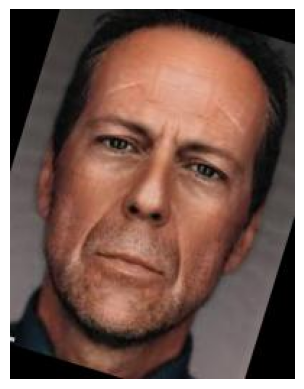

In [21]:
idx = 79
image_path = glob.glob(f"{test_dir}/**/*")[idx]
img = plt.imread(image_path)
plt.imshow(img)
plt.axis('off')
plt.show()

In [8]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=(128, 128),
    batch_size= 32
    )

Found 6042 files belonging to 2 classes.


In [25]:
test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=(128, 128),
    batch_size= 32 #Efficient for GPU/TPU training
    )

Found 1511 files belonging to 2 classes.


# 4. Preprocessing

In [10]:
from tensorflow.keras import layers, models

In [11]:
normalization_layer = layers.Rescaling(1./255)

In [12]:
train_ds_new = train_ds.map(lambda x, y: (normalization_layer(x), y))
test_ds_new = test_ds.map(lambda x, y: (normalization_layer(x), y))

NameError: name 'test_ds' is not defined

# 5. Convolution Architecture: Pre-trainied: Freeze entire layers

In [31]:
from tensorflow.keras.applications.resnet50 import ResNet50

In [32]:
base_model = ResNet50(input_shape=(128, 128, 3),
                     include_top=False,
                     weights='imagenet')

In [33]:
base_model.trainable = False

# 6. Fully Connected Layers:  ANN

In [35]:
model = Sequential()

model.add(base_model)
model.add(GlobalAveragePooling2D())

model.add(Dense(256, activation = "relu"))
model.add(BatchNormalization())
model.add(Dropout(0.2))

model.add(Dense(156, activation = "relu"))
model.add(BatchNormalization())
model.add(Dropout(0.2))


model.add(Dense(2, activation='softmax'))

In [36]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 resnet50 (Functional)       (None, 4, 4, 2048)        23587712  
                                                                 
 global_average_pooling2d (  (None, 2048)              0         
 GlobalAveragePooling2D)                                         
                                                                 
 dense (Dense)               (None, 256)               524544    
                                                                 
 batch_normalization (Batch  (None, 256)               1024      
 Normalization)                                                  
                                                                 
 dropout (Dropout)           (None, 256)               0         
                                                                 
 dense_1 (Dense)             (None, 156)               4

In [37]:
model.compile(optimizer= 'adam',
             loss='sparse_categorical_crossentropy',
             metrics=['accuracy'])

In [39]:
history = model.fit(train_ds_new, validation_data=test_ds_new, epochs=15, batch_size = 32)

Epoch 1/15
189/189 [==============================] - 557s 3s/step - loss: 0.5540 - accuracy: 0.7248 - val_loss: 0.6953 - val_accuracy: 0.6380
Epoch 2/15
189/189 [==============================] - 205s 1s/step - loss: 0.4956 - accuracy: 0.7668 - val_loss: 0.6122 - val_accuracy: 0.6817
Epoch 3/15
189/189 [==============================] - 148s 783ms/step - loss: 0.4697 - accuracy: 0.7759 - val_loss: 3.3321 - val_accuracy: 0.4931
Epoch 4/15
189/189 [==============================] - 152s 804ms/step - loss: 0.4525 - accuracy: 0.7908 - val_loss: 1.7493 - val_accuracy: 0.5083
Epoch 5/15
189/189 [==============================] - 158s 837ms/step - loss: 0.4214 - accuracy: 0.8011 - val_loss: 1.6564 - val_accuracy: 0.6314
Epoch 6/15
189/189 [==============================] - 152s 805ms/step - loss: 0.4171 - accuracy: 0.8054 - val_loss: 1.8213 - val_accuracy: 0.5784
Epoch 7/15
189/189 [==============================] - 153s 808ms/step - loss: 0.4048 - accuracy: 0.8100 - val_loss: 1.0477 - val_a

In [40]:
model.save("face_mask_model.h5")

# 7. Model Evaluation

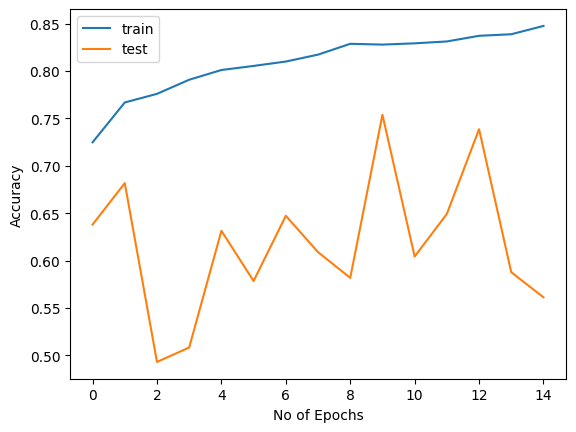

In [46]:
plt.plot(history.history['accuracy'], label = "train")
plt.plot(history.history['val_accuracy'], label = "test")
plt.legend()
plt.xlabel("No of Epochs")
plt.ylabel("Accuracy")
plt.show()

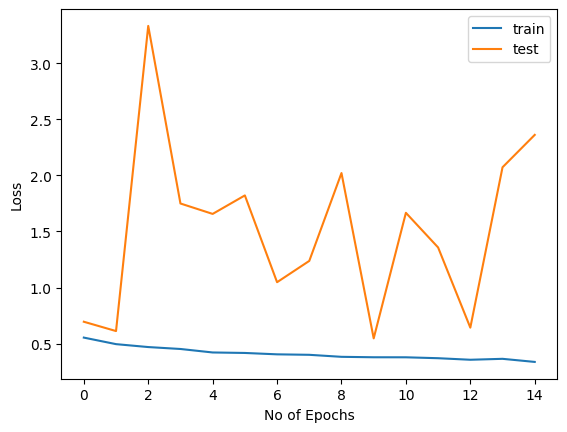

In [47]:
plt.plot(history.history['loss'], label = "train")
plt.plot(history.history['val_loss'], label = "test")
plt.legend()
plt.xlabel("No of Epochs")
plt.ylabel("Loss")
plt.show()

In [49]:
for x, y in test_ds_new:
    break

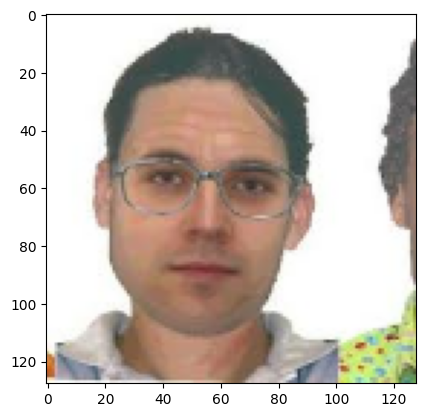

In [52]:
plt.imshow(x[0])

In [55]:
y_true = np.concatenate([y for x, y in test_ds_new], axis=0)

In [57]:
y_pred = np.argmax(model.predict(test_ds_new), axis = 1)

48/48 [==============================] - 31s 637ms/step


In [58]:
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

In [59]:
cm = confusion_matrix(y_true, y_pred)

In [60]:
cm

array([[ 49, 696],
       [ 49, 717]], dtype=int64)

In [61]:
accuracy_score(y_true, y_pred)

0.5069490403706155

In [62]:
print(classification_report(y_true, y_pred))

              precision    recall  f1-score   support

           0       0.50      0.07      0.12       745
           1       0.51      0.94      0.66       766

    accuracy                           0.51      1511
   macro avg       0.50      0.50      0.39      1511
weighted avg       0.50      0.51      0.39      1511



# Testing

In [15]:
model = tf.keras.models.load_model("face_mask_model.h5")

In [20]:
import ipywidgets as widgets
import cv2
import numpy as np
import PIL as Image

In [21]:
upload = widgets.FileUpload(accept = 'image/*', mulitle = False)
display(upload)

FileUpload(value=(), accept='image/*', description='Upload')

In [59]:
content = upload.value[0]['content']

In [60]:
nparr = np.frombuffer(content, np.uint8)
image = cv2.imdecode(nparr, cv2.IMREAD_COLOR)  # BGR
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)  # RGB for matplotlib

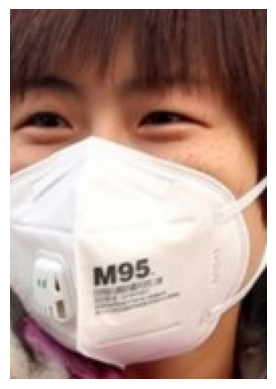

In [61]:
plt.imshow(image_rgb)
plt.axis('off')
plt.show()

In [62]:
img_resized = cv2.resize(image_rgb, (128, 128))
img_array = np.array(img_resized, dtype = 'float32')

In [63]:
nomralization_layer = layers.Rescaling(1./255)
img_normalized = nomralization_layer(img_array)

In [64]:
img_input = np.expand_dims(img_normalized, axis=0)# Add batch dimesion -> (1, hight, weight, 3)

In [65]:
y_pred = model.predict(img_input)

1/1 [==============================] - 0s 166ms/step


In [66]:
y_pred[0]

array([0.02608519, 0.97391486], dtype=float32)

No Mask Detected 0.97391486


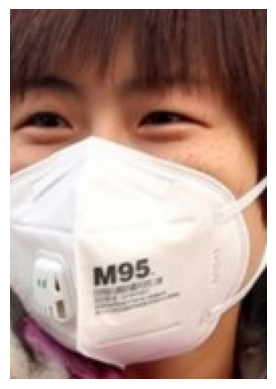

In [67]:
if y_pred[0][0]>y_pred[0][1]:
    print("Mask Detected", y_pred[0][0])
else:
    print("No Mask Detected", y_pred[0][1])
    
plt.imshow(image_rgb)
plt.axis('off')
plt.show()